In [1]:
import json
import csv
from pathlib import Path

def build_reply_pairs(data):
    # Сначала строим словарь: message_id -> сообщение
    messages_by_id = {}
    for msg in data.get("messages", []):
        if "id" in msg:
            messages_by_id[msg["id"]] = msg

    pairs = []
    for msg in data.get("messages", []):
        # Проверяем наличие reply_to_message_id
        reply_to = msg.get("reply_to_message_id")
        if reply_to and reply_to in messages_by_id:
            original = messages_by_id[reply_to]
            
            # Пропускаем служебные сообщения (например, "пользователь покинул чат")
            if original.get("type") != "message" or msg.get("type") != "message":
                continue
            
            pairs.append({
                "reply_id": original["id"],
                "reply_author": original.get("from", "Unknown"),
                "reply_text": original.get("text", ""),
                "message_id": msg["id"],
                "message_author": msg.get("from", "Unknown"),
                "message_text": msg.get("text", ""),
                "date": msg.get("date", "")
            })
    return pairs

def save_to_csv(pairs, output_file="replies.csv"):
    if not pairs:
        print("Нет сообщений с reply_to_message_id")
        return
    with open(output_file, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=pairs[0].keys())
        writer.writeheader()
        writer.writerows(pairs)
    print(f"Сохранено {len(pairs)} пар ответов в {output_file}")

if __name__ == "__main__":
    with open("data.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    
    pairs = build_reply_pairs(data)
    save_to_csv(pairs)

Сохранено 132937 пар ответов в replies.csv


Загрузка данных...
Данных много (132937), беру последние 50000...
Обработка 50000 сообщений...
Отрисовка сегментов...
Отрисовка линий...
Отрисовка 9504 линий...
Добавление подписей...


C:\Users\User\AppData\Local\Temp\ipykernel_19224\1496117030.py:345: UserWarning: Glyph 30561 (\N{CJK UNIFIED IDEOGRAPH-7761}) missing from font(s) DejaVu Sans.
  plt.savefig('chord_diagram_balanced.png', dpi=300, facecolor='black', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_19224\1496117030.py:345: UserWarning: Glyph 35273 (\N{CJK UNIFIED IDEOGRAPH-89C9}) missing from font(s) DejaVu Sans.
  plt.savefig('chord_diagram_balanced.png', dpi=300, facecolor='black', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_19224\1496117030.py:345: UserWarning: Glyph 128126 (\N{ALIEN MONSTER}) missing from font(s) DejaVu Sans.
  plt.savefig('chord_diagram_balanced.png', dpi=300, facecolor='black', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_19224\1496117030.py:345: UserWarning: Glyph 127797 (\N{CACTUS}) missing from font(s) DejaVu Sans.
  plt.savefig('chord_diagram_balanced.png', dpi=300, facecolor='black', bbox_inches='tight')
C:\Users\User\AppDa

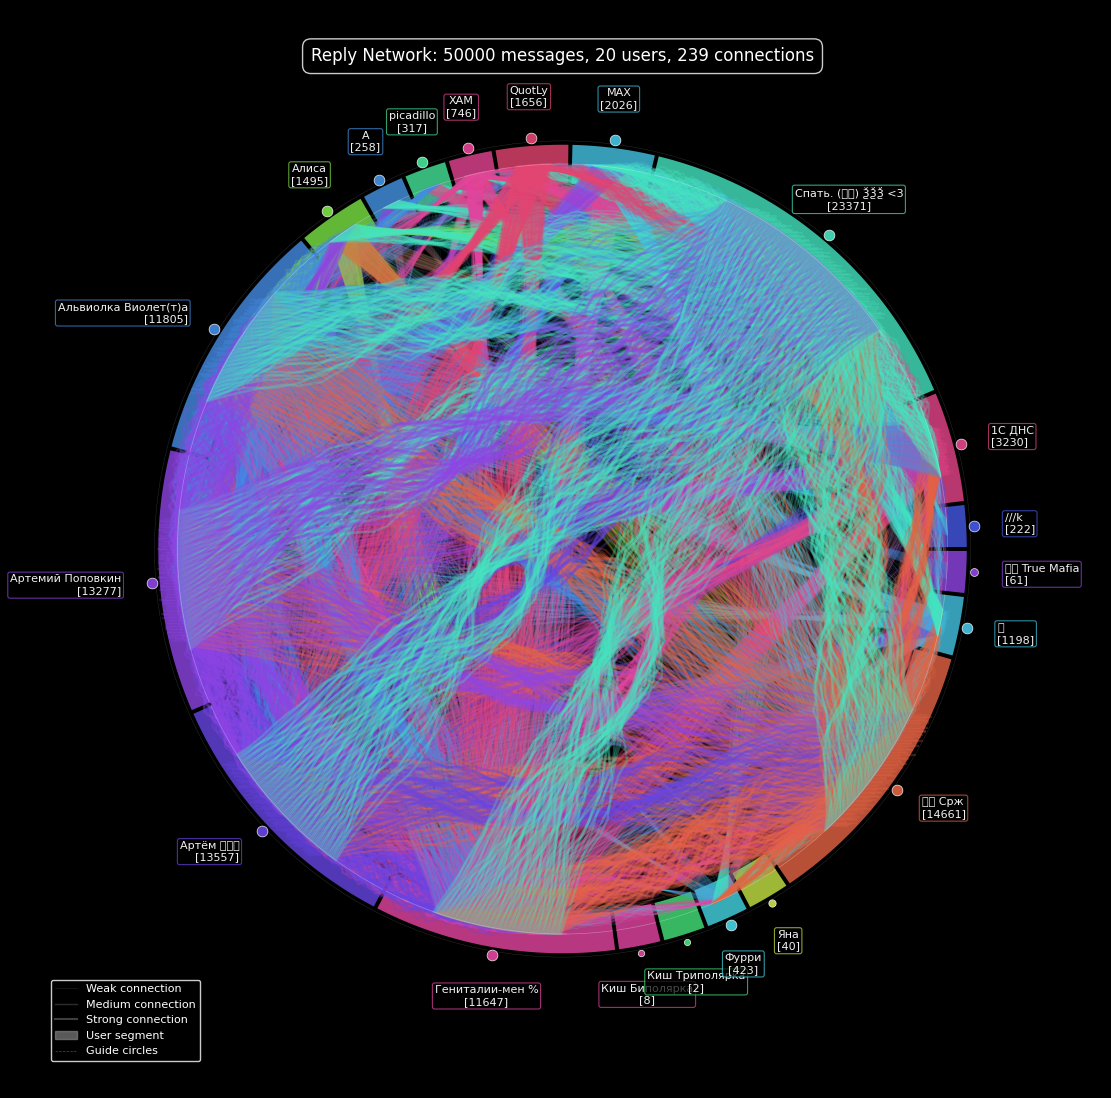


=== Статистика ===
Всего пользователей: 20
Всего сообщений: 50000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import matplotlib.patches as patches
from collections import defaultdict
import colorsys

def smooth_curve_fast(t_points, y_points, smooth_iterations=8):
    """
    Оптимизированная версия сглаживания
    """
    cs = CubicSpline(t_points, y_points, bc_type='natural')
    new_t = np.linspace(0, 1, 100)  # Уменьшил количество точек для скорости
    new_y = cs(new_t)
    
    # Векторизованное сглаживание
    for _ in range(smooth_iterations):
        smooth_y = new_y.copy()
        smooth_y[1:-1] = (new_y[:-2] + new_y[1:-1] + new_y[2:]) / 3
        new_y = smooth_y
    
    return new_t, new_y

def create_wavy_line_fast(start_angle, end_angle, radius=1.0, 
                          noise_amplitude=0.12, wave_frequency=2,
                          offset=0):
    """
    Быстрое создание волнистой линии (без отрисовки)
    Возвращает координаты линии
    """
    # Точки на окружности
    x1, y1 = radius * np.cos(start_angle), radius * np.sin(start_angle)
    x2, y2 = radius * np.cos(end_angle), radius * np.sin(end_angle)
    
    # Создаём базовую линию с меньшим количеством точек
    t = np.linspace(0, 1, 50)  # Уменьшено с 200 до 50
    
    # Линейная интерполяция
    x = x1 + (x2 - x1) * t
    y = y1 + (y2 - y1) * t
    
    # Вектор перпендикулярный направлению линии
    dx, dy = x2 - x1, y2 - y1
    length = np.sqrt(dx**2 + dy**2)
    if length > 0:
        perp_x = -dy / length
        perp_y = dx / length
    else:
        perp_x, perp_y = 1, 0
    
    # Огибающая (0 на краях, 1 в середине)
    envelope = np.sin(np.pi * t)
    
    # Быстрое создание шума с использованием векторизации
    wave = np.sin(wave_frequency * np.pi * t) * noise_amplitude * 0.7
    random_noise = np.random.uniform(-noise_amplitude * 0.3, noise_amplitude * 0.3, len(t))
    
    # Простое сглаживание шума
    random_noise = np.convolve(random_noise, np.ones(3)/3, mode='same')
    
    # Применяем смещение
    total_noise = (wave + random_noise) * envelope * (1 + offset * 0.3)
    
    x += perp_x * total_noise
    y += perp_y * total_noise
    
    return x, y

def draw_arc_segment_fast(ax, start_angle, end_angle, radius, color, width=0.05):
    """
    Оптимизированная отрисовка сегмента дуги
    """
    theta = np.linspace(start_angle, end_angle, 50)  # Уменьшено количество точек
    inner_r = radius - width/2
    outer_r = radius + width/2
    
    # Предварительное выделение массивов
    outer_x = outer_r * np.cos(theta)
    outer_y = outer_r * np.sin(theta)
    inner_x = inner_r * np.cos(theta[::-1])
    inner_y = inner_r * np.sin(theta[::-1])
    
    vertices = np.column_stack([np.concatenate([outer_x, inner_x]),
                                np.concatenate([outer_y, inner_y])])
    
    polygon = patches.Polygon(vertices, color=color, alpha=0.7, linewidth=0)
    ax.add_patch(polygon)

def process_data_optimized(data, max_messages=100000):
    """
    Предварительная обработка данных с агрегацией
    """
    # Ограничиваем количество сообщений если нужно
    if len(data) > max_messages:
        data = data.sample(n=max_messages, random_state=42)
    
    # Быстрая агрегация активности
    sent = data.groupby('from').size()
    received = data.groupby('to').size()
    
    all_users = sorted(set(data['from']).union(set(data['to'])))
    
    # Генерация цветов для пользователей
    user_colors = {}
    for i, user in enumerate(all_users):
        hue = (hash(user) % 360) / 360.0
        user_colors[user] = colorsys.hsv_to_rgb(hue, 0.7, 0.9)
    
    # Агрегация активности
    activity = defaultdict(int)
    for u in all_users:
        activity[u] = sent.get(u, 0) + received.get(u, 0)
    
    total = sum(activity.values())
    
    # Вычисление углов
    angles = {}
    start = 0
    for u in all_users:
        frac = activity[u] / total
        angles[u] = (start, start + 2 * np.pi * frac)
        start += 2 * np.pi * frac
    
    # Группировка сообщений по парам
    messages_by_pair = data.groupby(['from', 'to']).size().reset_index(name='count')
    
    return data, all_users, user_colors, sent, received, activity, angles, messages_by_pair

def plot_chord_diagram_fast(data, ax=None, title="Reply Network Visualization"):
    """
    Оптимизированная отрисовка хордовой диаграммы
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_facecolor('black')
        fig.patch.set_facecolor('black')
    
    # Предварительная обработка данных
    data, all_users, user_colors, sent, received, activity, angles, messages_by_pair = process_data_optimized(data)
    
    print("Отрисовка сегментов...")
    # Рисуем цветные сегменты
    for user, (a_start, a_end) in angles.items():
        color = user_colors[user]
        draw_arc_segment_fast(ax, a_start, a_end, radius=1.0, color=color, width=0.05)
    
    print("Отрисовка линий...")
    # Кэширование для линий с одинаковыми параметрами
    line_cache = {}
    
    # Сортируем пары по количеству сообщений для оптимальной отрисовки
    messages_by_pair = messages_by_pair.sort_values('count', ascending=False)
    
    # Предварительное вычисление всех линий
    lines_to_draw = []
    
    for _, row in messages_by_pair.iterrows():
        from_user = row['from']
        to_user = row['to']
        count = min(row['count'], 50)  # Ограничиваем максимальное количество линий на пару
        
        start_a, end_a = angles[from_user]
        start_b, end_b = angles[to_user]
        line_color = user_colors[from_user]
        
        # Параметры линии
        alpha = min(0.05, 0.001 + count * 0.001)
        linewidth = 0.2 + count * 0.01
        noise_amplitude = 0.001 + count * 0.0001
        
        # Создаём ключ для кэша
        cache_key = (from_user, to_user, count)
        
        for i in range(count):
            # Позиция в пучке
            t = -1 + (2 * i / max(1, count - 1)) if count > 1 else 0
            
            # Равномерно распределяем углы
            angle_from = start_a + (end_a - start_a) * (0.5 + t * 0.45)
            angle_to = start_b + (end_b - start_b) * (0.5 + t * 0.45)
            
            angle_from = np.clip(angle_from, start_a, end_a)
            angle_to = np.clip(angle_to, start_b, end_b)
            
            # Создаём линию
            x_line, y_line = create_wavy_line_fast(
                angle_from, angle_to,
                radius=1.0,
                noise_amplitude=noise_amplitude,
                wave_frequency=2 + (i % 3),
                offset=t * 0.2
            )
            
            lines_to_draw.append((x_line, y_line, line_color, linewidth, alpha))
    
    # Пакетная отрисовка всех линий
    print(f"Отрисовка {len(lines_to_draw)} линий...")
    for x_line, y_line, color, lw, alpha in lines_to_draw:
        ax.plot(x_line, y_line, color=color, linewidth=lw, alpha=alpha, 
                solid_capstyle='round', zorder=1)
    
    print("Добавление подписей...")
    # Подписи участников
    for user, (a_start, a_end) in angles.items():
        mid = (a_start + a_end) / 2
        radius = 1.18
        x = radius * np.cos(mid)
        y = radius * np.sin(mid)
        
        s = sent.get(user, 0)
        r = received.get(user, 0)
        color = user_colors[user]
        
        # Определяем выравнивание
        cos_mid = np.cos(mid)
        sin_mid = np.sin(mid)
        
        if cos_mid > 0.75:
            ha = 'left'
        elif cos_mid < -0.75:
            ha = 'right'
        else:
            ha = 'center'
            
        if sin_mid > 0.75:
            va = 'bottom'
        elif sin_mid < -0.75:
            va = 'top'
        else:
            va = 'center'
        
        # Цветной кружок
        dot_x = x - 0.07 * cos_mid
        dot_y = y - 0.07 * sin_mid
        ax.scatter(dot_x, dot_y, color=color, s=30, alpha=0.8, zorder=5)
        
        ax.text(x, y, f'{user}\n({s}→, {r}←)', color='white', 
                ha=ha, va=va, fontsize=8, alpha=0.95,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6, 
                         edgecolor=color, linewidth=0.5),
                zorder=5)
    
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.axis('off')
    
    return ax

# =============================
# Основной код
# =============================
if __name__ == "__main__":
    # Загрузка данных (можно читать по частям)
    print("Загрузка данных...")
    data = pd.read_csv('replies.csv')
    
    # Если данных очень много, можно взять только последние N записей
    # или случайную выборку
    if len(data) > 50000:
        print(f"Данных много ({len(data)}), беру случайную выборку...")
        data = data.tail(50000)  # Или data.sample(50000, random_state=42)
    
    print(f"Обработка {len(data)} сообщений...")
    
    # Создаём диаграмму
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    
    # Отрисовка
    plot_chord_diagram_fast(data, ax)
    
    # Сохранение
    plt.savefig('chord_diagram_optimized.png', dpi=200, facecolor='black', bbox_inches='tight')
    plt.show()
    
    # Статистика
    print("\n=== Статистика ===")
    print(f"Всего пользователей: {len(set(data['from']).union(set(data['to'])))}")
    print(f"Всего сообщений: {len(data)}")
    print(f"Уникальных пар: {len(data.groupby(['from', 'to']))}")

Загрузка данных...
Исходные данные: 132937 сообщений

Фильтрация пользователей...
Отфильтровано: 15 пользователей с активностью < 500
Осталось пользователей: 17
Осталось сообщений: 132343 (было 132937)

Обработка 132343 сообщений...
Отрисовка сегментов...
Отрисовка линий...
Отрисовка 10159 линий...
Добавление подписей...


C:\Users\User\AppData\Local\Temp\ipykernel_19224\1907829757.py:356: UserWarning: Glyph 30561 (\N{CJK UNIFIED IDEOGRAPH-7761}) missing from font(s) DejaVu Sans.
  plt.savefig('chord_diagram_filtered.png', dpi=300, facecolor='black', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_19224\1907829757.py:356: UserWarning: Glyph 35273 (\N{CJK UNIFIED IDEOGRAPH-89C9}) missing from font(s) DejaVu Sans.
  plt.savefig('chord_diagram_filtered.png', dpi=300, facecolor='black', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_19224\1907829757.py:356: UserWarning: Glyph 128126 (\N{ALIEN MONSTER}) missing from font(s) DejaVu Sans.
  plt.savefig('chord_diagram_filtered.png', dpi=300, facecolor='black', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_19224\1907829757.py:356: UserWarning: Glyph 127797 (\N{CACTUS}) missing from font(s) DejaVu Sans.
  plt.savefig('chord_diagram_filtered.png', dpi=300, facecolor='black', bbox_inches='tight')
C:\Users\User\AppDa

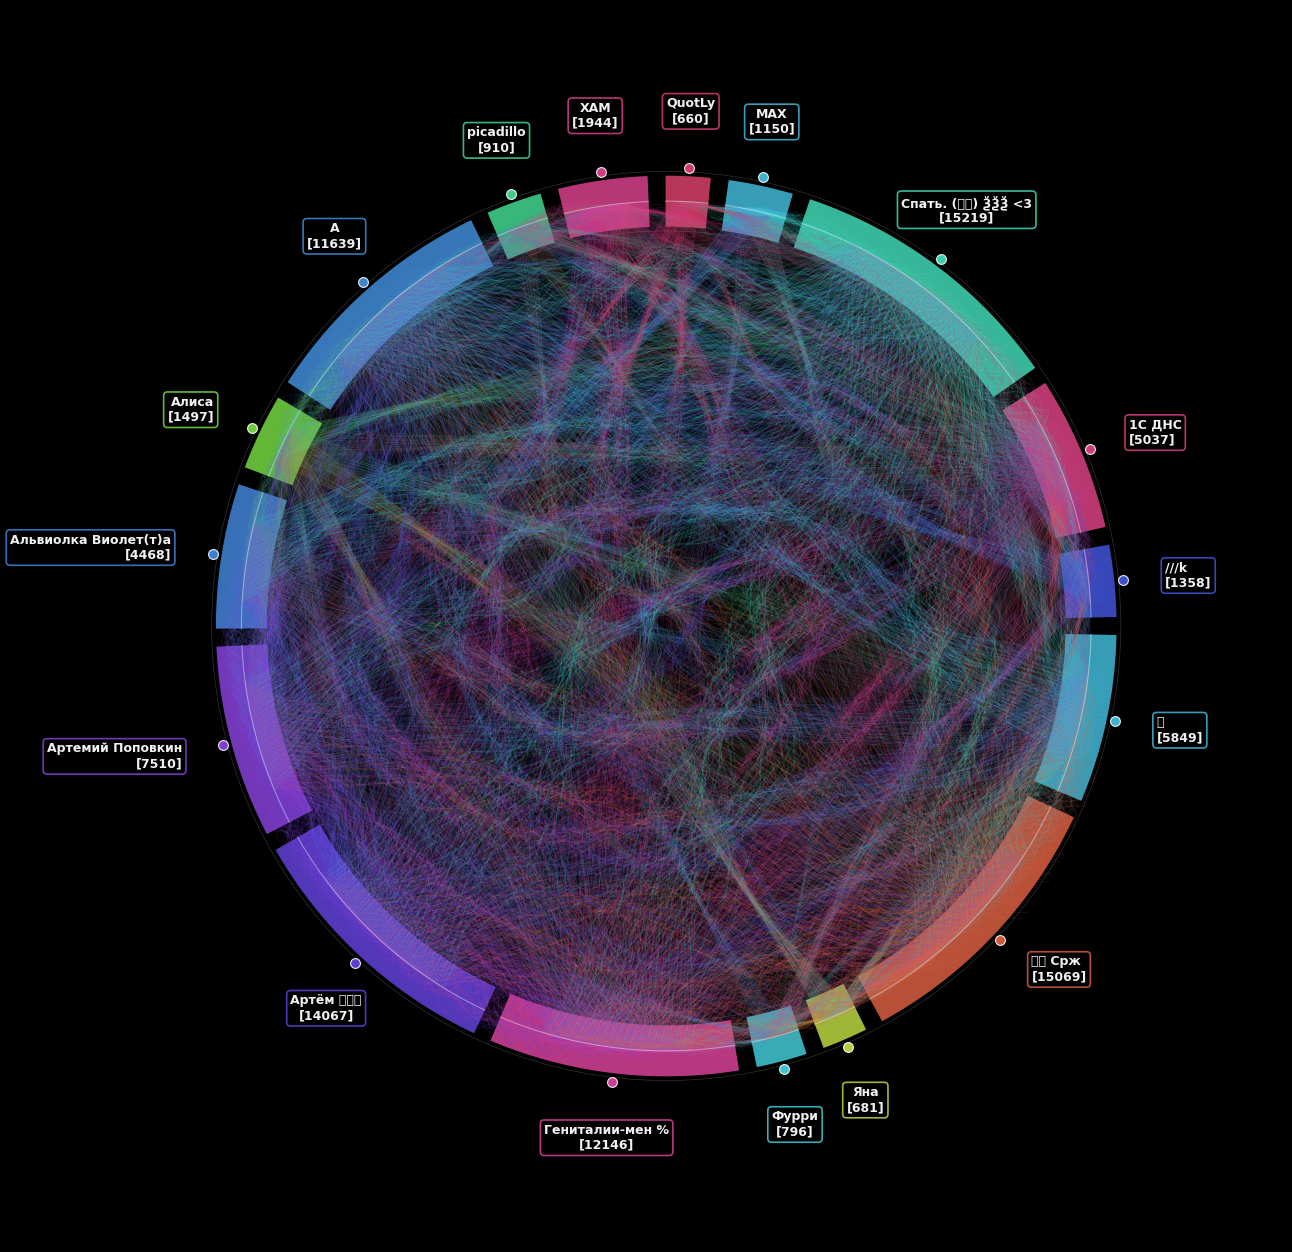


=== ИТОГОВАЯ СТАТИСТИКА ===
Активных пользователей (>=10 реплаев): 17
Всего сообщений: 132343
Уникальных пар: 268

Топ-5 активных пользователей:
  Cпaть. (睡觉) ѮѮѮ <3: 40409 реплаев (21139→, 19270←)
  春天 Срж: 39592 реплаев (21476→, 18116←)
  Артём 👾🌵🥔: 37549 реплаев (18119→, 19430←)
  Гениталии-мен %: 32113 реплаев (13187→, 18926←)
  А: 30728 реплаев (14803→, 15925←)


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import matplotlib.patches as patches
from collections import defaultdict
import colorsys

def smooth_curve_fast(t_points, y_points, smooth_iterations=8):
    """
    Оптимизированная версия сглаживания
    """
    cs = CubicSpline(t_points, y_points, bc_type='natural')
    new_t = np.linspace(0, 1, 100)
    new_y = cs(new_t)
    
    for _ in range(smooth_iterations):
        smooth_y = new_y.copy()
        smooth_y[1:-1] = (new_y[:-2] + new_y[1:-1] + new_y[2:]) / 3
        new_y = smooth_y
    
    return new_t, new_y

def create_wavy_line_fast(start_angle, end_angle, radius=1.0, 
                          noise_amplitude=0.12, wave_frequency=2,
                          offset=0, strength=1.0):
    """
    Быстрое создание волнистой линии
    strength - дополнительный параметр для усиления/ослабления изгиба
    """
    x1, y1 = radius * np.cos(start_angle), radius * np.sin(start_angle)
    x2, y2 = radius * np.cos(end_angle), radius * np.sin(end_angle)
    
    t = np.linspace(0, 1, 50)
    
    x = x1 + (x2 - x1) * t
    y = y1 + (y2 - y1) * t
    
    dx, dy = x2 - x1, y2 - y1
    length = np.sqrt(dx**2 + dy**2)
    if length > 0:
        perp_x = -dy / length
        perp_y = dx / length
    else:
        perp_x, perp_y = 1, 0
    
    envelope = np.sin(np.pi * t)
    
    # Усиление волн для сильных связей
    wave = np.sin(wave_frequency * np.pi * t) * noise_amplitude * 0.7 * strength
    random_noise = np.random.uniform(-noise_amplitude * 0.3, noise_amplitude * 0.3, len(t))
    random_noise = np.convolve(random_noise, np.ones(3)/3, mode='same')
    
    total_noise = (wave + random_noise) * envelope * (1 + offset * 0.3) * strength
    
    x += perp_x * total_noise
    y += perp_y * total_noise
    
    return x, y

def draw_arc_segment_with_gap(ax, start_angle, end_angle, radius, color, width=0.08, gap=0.2):
    """
    Рисует сегмент дуги с зазором между сегментами
    """
    # Уменьшаем углы для создания зазора
    adjusted_start = start_angle + gap
    adjusted_end = end_angle - gap
    
    if adjusted_end <= adjusted_start:
        return
    
    theta = np.linspace(adjusted_start, adjusted_end, 50)
    inner_r = radius - width/2
    outer_r = radius + width/2
    
    outer_x = outer_r * np.cos(theta)
    outer_y = outer_r * np.sin(theta)
    inner_x = inner_r * np.cos(theta[::-1])
    inner_y = inner_r * np.sin(theta[::-1])
    
    vertices = np.column_stack([np.concatenate([outer_x, inner_x]),
                                np.concatenate([outer_y, inner_y])])
    
    polygon = patches.Polygon(vertices, color=color, alpha=0.8, linewidth=0)
    ax.add_patch(polygon)
    
    # Добавляем белую границу для лучшего разделения
    edge_x = radius * np.cos(theta)
    edge_y = radius * np.sin(theta)
    ax.plot(edge_x, edge_y, color='white', linewidth=0.8, alpha=0.4)

def filter_users_by_activity(data, min_activity=500):
    """
    Фильтрует пользователей с активностью меньше min_activity
    """
    # Считаем активность каждого пользователя
    sent = data.groupby('from').size()
    received = data.groupby('to').size()
    
    all_users = set(data['from']).union(set(data['to']))
    active_users = set()
    
    for user in all_users:
        total = sent.get(user, 0) + received.get(user, 0)
        if total >= min_activity:
            active_users.add(user)
    
    # Фильтруем данные
    filtered_data = data[data['from'].isin(active_users) & data['to'].isin(active_users)]
    
    print(f"Отфильтровано: {len(all_users) - len(active_users)} пользователей с активностью < {min_activity}")
    print(f"Осталось пользователей: {len(active_users)}")
    print(f"Осталось сообщений: {len(filtered_data)} (было {len(data)})")
    
    return filtered_data

def process_data_balanced(data, min_angle_frac=0.02, max_messages=50000):
    """
    Обработка данных с балансировкой размеров дуг
    min_angle_frac - минимальная доля угла для пользователя (чтобы все были видны)
    """
    if len(data) > max_messages:
        data = data.sample(n=max_messages, random_state=42)
    
    sent = data.groupby('from').size()
    received = data.groupby('to').size()
    
    all_users = sorted(set(data['from']).union(set(data['to'])))
    
    # Генерация цветов
    user_colors = {}
    for user in all_users:
        hue = (hash(user) % 360) / 360.0
        user_colors[user] = colorsys.hsv_to_rgb(hue, 0.7, 0.9)
    
    # Агрегация активности с логарифмическим масштабированием для баланса
    activity_raw = {u: sent.get(u, 0) + received.get(u, 0) for u in all_users}
    max_activity = max(activity_raw.values())
    
    # Применяем степенное преобразование для балансировки
    # Маленькие дуги становятся чуть больше, большие - чуть меньше
    balance_power = 0.5  # Ещё больше балансируем
    
    activity_balanced = {}
    for u, act in activity_raw.items():
        # Нормализуем и применяем степенную функцию
        norm_act = act / max_activity if max_activity > 0 else 0
        balanced_act = norm_act ** balance_power
        activity_balanced[u] = balanced_act
    
    total_balanced = sum(activity_balanced.values())
    
    # Вычисляем углы с минимальной гарантированной долей
    angles = {}
    start = 0
    
    for u in all_users:
        # Базовая доля из сбалансированной активности
        base_frac = activity_balanced[u] / total_balanced
        # Гарантируем минимальный размер (увеличил для лучшей видимости)
        frac = max(base_frac, min_angle_frac)
        angles[u] = (start, start + 2 * np.pi * frac)
        start += 2 * np.pi * frac
    
    # Нормализуем углы, чтобы сумма была 2π
    total_angle = sum(end - start for start, end in angles.values())
    scale_factor = 2 * np.pi / total_angle
    
    normalized_angles = {}
    current_start = 0
    for u, (start_a, end_a) in angles.items():
        length = (end_a - start_a) * scale_factor
        normalized_angles[u] = (current_start, current_start + length)
        current_start += length
    
    # Группировка сообщений с вычислением силы связи
    messages_by_pair = data.groupby(['from', 'to']).size().reset_index(name='count')
    
    # Вычисляем силу связи (логарифмическая шкала для лучшей визуализации)
    max_count = messages_by_pair['count'].max()
    messages_by_pair['strength'] = np.log1p(messages_by_pair['count']) / np.log1p(max_count)
    
    return (data, all_users, user_colors, sent, received, 
            activity_raw, normalized_angles, messages_by_pair)

def plot_chord_diagram_balanced(data, ax=None):
    """
    Улучшенная диаграмма с балансировкой и увеличенными зазорами
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 16))
        ax.set_facecolor('black')
        fig.patch.set_facecolor('black')
    
    # Обработка данных с балансировкой
    (data, all_users, user_colors, sent, received, 
     activity_raw, angles, messages_by_pair) = process_data_balanced(data)
    
    # ===== Рисуем сегменты с увеличенными зазорами =====
    print("Отрисовка сегментов...")
    gap_size = 0.02  # Увеличенный зазор
    segment_width = 0.12  # Чуть шире сегменты
    
    for user, (a_start, a_end) in angles.items():
        color = user_colors[user]
        draw_arc_segment_with_gap(ax, a_start, a_end, radius=1.0, 
                                  color=color, width=segment_width, gap=gap_size)
    
    # Добавляем декоративные круги
    for r in [0.93, 1.07]:
        circle = plt.Circle((0, 0), r, color='white', fill=False, linewidth=0.5, alpha=0.2)
        ax.add_artist(circle)
    
    # Добавляем внутренний круг для акцента
    inner_circle = plt.Circle((0, 0), 0.85, color='white', fill=False, linewidth=0.3, alpha=0.15)
    ax.add_artist(inner_circle)
    
    # ===== Рисуем линии с усилением сильных связей =====
    print("Отрисовка линий...")
    
    # Сортируем по силе связи (сильные рисуем первыми, они будут на заднем плане)
    messages_by_pair = messages_by_pair.sort_values('strength', ascending=True)
    
    lines_to_draw = []
    
    for _, row in messages_by_pair.iterrows():
        from_user = row['from']
        to_user = row['to']
        count = row['count']
        strength = row['strength']
        
        start_a, end_a = angles[from_user]
        start_b, end_b = angles[to_user]
        line_color = user_colors[from_user]
        
        # Динамические параметры в зависимости от силы связи
        max_lines_per_pair = min(count, 60)  # Ограничиваем для производительности
        
        # Настройки видимости для сильных связей
        alpha = 0.02 + strength * 0.1
        linewidth = 0.2 + strength * 0.6
        noise_amplitude = 0.04 + strength * 0.12
        bundle_curve = 0.3 + strength * 0.4
        
        for i in range(max_lines_per_pair):
            # Позиция в пучке
            if max_lines_per_pair > 1:
                t = -1 + (2 * i / (max_lines_per_pair - 1))
            else:
                t = 0
            
            # Углы с учётом силы связи
            focus = 0.25 + strength * 0.5
            angle_from = start_a + (end_a - start_a) * (0.5 + t * focus * 0.4)
            angle_to = start_b + (end_b - start_b) * (0.5 + t * focus * 0.4)
            
            angle_from = np.clip(angle_from, start_a, end_a)
            angle_to = np.clip(angle_to, start_b, end_b)
            
            x_line, y_line = create_wavy_line_fast(
                angle_from, angle_to,
                radius=1.0,
                noise_amplitude=noise_amplitude,
                wave_frequency=2 + (i % 3),
                offset=t * bundle_curve * 0.3,
                strength=strength
            )
            
            lines_to_draw.append((x_line, y_line, line_color, linewidth, alpha))
    
    # Пакетная отрисовка
    print(f"Отрисовка {len(lines_to_draw)} линий...")
    for x_line, y_line, color, lw, alpha in lines_to_draw:
        ax.plot(x_line, y_line, color=color, linewidth=lw, alpha=alpha, 
                solid_capstyle='round', zorder=1)
    
    # ===== Подписи с информацией об активности =====
    print("Добавление подписей...")
    
    for user, (a_start, a_end) in angles.items():
        mid = (a_start + a_end) / 2
        radius = 1.18  # Немного дальше из-за увеличенных сегментов
        x = radius * np.cos(mid)
        y = radius * np.sin(mid)
        
        s = sent.get(user, 0)
        r = received.get(user, 0)
        total_act = activity_raw[user]
        color = user_colors[user]
        
        # Определяем выравнивание
        cos_mid = np.cos(mid)
        sin_mid = np.sin(mid)
        
        if cos_mid > 0.7:
            ha = 'left'
        elif cos_mid < -0.7:
            ha = 'right'
        else:
            ha = 'center'
            
        if sin_mid > 0.7:
            va = 'bottom'
        elif sin_mid < -0.7:
            va = 'top'
        else:
            va = 'center'
        
        # Цветной индикатор
        dot_x = x - 0.1 * cos_mid
        dot_y = y - 0.1 * sin_mid
        
        # Размер кружка пропорционален активности (логарифмически)
        dot_size = 15 + min(35, np.log1p(total_act) * 10)
        ax.scatter(dot_x, dot_y, color=color, s=dot_size, alpha=0.9, 
                  edgecolor='white', linewidth=0.8, zorder=5)
        
        # Добавляем тень для текста
        ax.text(x, y, f'{user}\n[{total_act}]', color='white', 
                ha=ha, va=va, fontsize=9, alpha=0.95, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.8, 
                         edgecolor=color, linewidth=1.2),
                zorder=5)
    
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_aspect('equal')
    ax.axis('off')
    
    return ax

# =============================
# Основной код
# =============================
if __name__ == "__main__":
    print("Загрузка данных...")
    data = pd.read_csv('replies.csv')
    print(f"Исходные данные: {len(data)} сообщений")
    
    # Фильтруем пользователей с активностью >= 10
    print("\nФильтрация пользователей...")
    data = filter_users_by_activity(data, min_activity=500)
    
    if len(data) == 0:
        print("Нет данных после фильтрации!")
        exit()
    
    print(f"\nОбработка {len(data)} сообщений...")
    
    fig, ax = plt.subplots(figsize=(16, 16))
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    
    plot_chord_diagram_balanced(data, ax)
    
    plt.savefig('chord_diagram_filtered.png', dpi=300, facecolor='black', bbox_inches='tight')
    plt.show()
    
    # Статистика
    print("\n=== ИТОГОВАЯ СТАТИСТИКА ===")
    print(f"Активных пользователей (>=10 реплаев): {len(set(data['from']).union(set(data['to'])))}")
    print(f"Всего сообщений: {len(data)}")
    print(f"Уникальных пар: {len(data.groupby(['from', 'to']))}")
    
    # Топ-5 самых активных пользователей
    sent = data.groupby('from').size()
    received = data.groupby('to').size()
    total_activity = {}
    for user in set(data['from']).union(set(data['to'])):
        total_activity[user] = sent.get(user, 0) + received.get(user, 0)
    
    top_users = sorted(total_activity.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\nТоп-5 активных пользователей:")
    for user, act in top_users:
        print(f"  {user}: {act} реплаев ({sent.get(user, 0)}→, {received.get(user, 0)}←)")